# **2. DATA UNDERSTANDING**

## **LIBRARIES**

In [ ]:
! pip install adlfs azure-storage-blob

In [ ]:
# Standard Library
import os
import io

# DATA MANIPULATION AND ANALYSIS
import pandas as pd
import numpy as np

# DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# AZURE CLOUD STORAGE
from adlfs import AzureBlobFileSystem
from azure.storage.blob import BlobServiceClient

# Regular expressions
import re

## **EXTRACT FROM AZURE BLOB STORAGE**

In [ ]:
pd.set_option("display.max_rows", None)
pd.set_option('display.max_columns', None)

In [ ]:
# Connection configuration
AZURE_STORAGE_ACCOUNT = "researchprojectx24104515"
AZURE_STORAGE_KEY = "bxpexO6i+Hz6n1WiipTn+sTCuLPGMS1BogMERrIrHd16DpQ0GLfQ0R33yrSw4MxsDomq5yNMgw1o+AStlx/MjA=="
CONTAINER_NAME = "cycle"

# Establish connection
connection_string = f"DefaultEndpointsProtocol=https;AccountName={AZURE_STORAGE_ACCOUNT};AccountKey={AZURE_STORAGE_KEY};EndpointSuffix=core.windows.net"
blob_service_client = BlobServiceClient.from_connection_string(connection_string)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

fs = AzureBlobFileSystem(
    account_name=AZURE_STORAGE_ACCOUNT,
    account_key=AZURE_STORAGE_KEY
)

### **FROM BLOB TO DATAFRAME**

In [ ]:
## List of CSV files in Blob
def list_csv_files_in_blob(container_client, verbose=True):
    csv_files = [blob.name for blob in container_client.list_blobs() if blob.name.endswith(".csv")]
    if verbose:
        print(f"CSV files found ({len(csv_files)}):")
        for i, file in enumerate(csv_files, 1):
            print(f"{i}. {file}")
    return csv_files

# Load CSV from Blob
def load_csvs_from_blob(container_client, csv_files, verbose=True):
    data = {}
    for file_name in csv_files:
        try:
            if verbose:
                print(f"\nLoading {file_name} as original data...")
            blob_client = container_client.get_blob_client(file_name)
            stream = blob_client.download_blob()
            data_bytes = stream.readall()
            data_str = data_bytes.decode("utf-8")

            # Extract year from filename
            year_match = re.search(r"(\d{4})", file_name)
            key = year_match.group(1) if year_match else file_name

            data[key] = data_str

            if verbose:
                lines = data_str.split("\n")
                print(f" -First 5 lines of '{file_name}':")
                for i, line in enumerate(lines[:5]):
                    print(f"    {i+1}: {line}")
                print(f" -Total lines: {len(lines)}")
        except Exception as e:
            print(f" -Error loading {file_name}: {e}")
    return data

# Convert CSV Dictionary to Dataframes
def convert_to_dataframe(original_data):
    data_dict = {}
    for key, raw_data in original_data.items():
        try:
            dataframe = pd.read_csv(io.StringIO(raw_data))
            data_dict[key] = dataframe
            print(f"Converted raw data for {key} to DataFrame with shape: {dataframe.shape}")
        except Exception as e:
            print(f"Error converting raw data for {key}: {e}")
    return data_dict
# Normalise Datetime column
def normalise_datetime(dataframes_dict, target_name="Date and time", time_terms=None):
    if time_terms is None:
        time_terms = ["time", "date", "hour"]

    for key, data in dataframes_dict.items():
        if len(data.columns) > 0:
            first_col = data.columns[0]
            if any(term in first_col.lower() for term in time_terms):
                data.rename(columns={first_col: target_name}, inplace=True)
                print(f"DataFrame {key}: Column '{first_col}' renamed as '{target_name}'")
            else:
                print(f"DataFrame {key}: The first column is '{first_col}', it does not seem to be a Date/Time column")
        else:
            print(f"DataFrame {key}: No columns included")
    return dataframes_dict


# Parse datetime formats
def parse_dates_in_dataframes(dataframes_dict, datetime_col="Date and time"):
    formats = [
        "%d-%m-%Y %H:%M:%S",
        "%d/%m/%Y %H:%M",
        "%Y-%m-%d %H:%M:%S",
        "%d/%m/%Y"
    ]
    def try_parse(date_str):
        if pd.isna(date_str):
            return pd.NaT
        for fmt in formats:
            try:
                return pd.to_datetime(date_str, format=fmt)
            except Exception:
                continue
        return pd.to_datetime(date_str, errors='coerce')

    for key, data in dataframes_dict.items():
        if datetime_col in data.columns:
            before_nat = data[datetime_col].isna().sum()
            data[datetime_col] = data[datetime_col].apply(try_parse)
            after_nat = data[datetime_col].isna().sum()
            print(f"DataFrame {key}: Parsed '{datetime_col}' ({before_nat} → {after_nat} NaT)")
        else:
            print(f"DataFrame {key}: No '{datetime_col}' column found.")
    return dataframes_dict

# Concatenate dataframes by name
def concatenate_all(data_dict):
    concatenated = pd.concat(
        data_dict.values(),
        axis=0,
        ignore_index=True,
        sort=True
    )

    print(f"Shape of concatenated dataframe : {concatenated.shape}")
    print(f"Columns in concatenated dataframe: {list(concatenated.columns)}")
    return concatenated

### **APPLY ALL FUNCTIONS TO READ**

In [ ]:
csv_files = list_csv_files_in_blob(container_client)
data = load_csvs_from_blob(container_client, csv_files)
data_yearly = convert_to_dataframe(data)
data_yearly = normalise_datetime(data_yearly)
data_yearly = parse_dates_in_dataframes(data_yearly)
cycle = concatenate_all(data_yearly)
cycle.head()

CSV files found (7):
1. cycle-jan-9mar-2025.csv
2. cycle-jan-dec-2019.csv
3. cycle-jan-dec-2020.csv
4. cycle-jan-dec-2021.csv
5. cycle-jan-dec-2022.csv
6. cycle-jan-dec-2023.csv
7. cycle-jan-dec-2024.csv

Loading cycle-jan-9mar-2025.csv as original data...
 -First 5 lines of 'cycle-jan-9mar-2025.csv':
    1: Time,Charleville Mall (Unable to Reinstall Repaired Counter due to Roadworks 23.08.2023),Charleville Mall (Unable to Reinstall Repaired Counter due to Roadworks 23.08.2023) North Cyclist,Charleville Mall (Unable to Reinstall Repaired Counter due to Roadworks 23.08.2023) South Cyclist,Clontarf - James Larkin Rd,Clontarf - James Larkin Rd Cyclist West,Clontarf - James Larkin Rd Cyclist East,Clontarf - Pebble Beach Carpark,Clontarf - Pebble Beach Carpark Cyclist West,Clontarf - Pebble Beach Carpark Cyclist East,Drumcondra Cyclists Inbound (Not On Site - Roadworks) Cyclist,Drumcondra Cyclists Inbound (Not On Site - Roadworks) Cyclist West,Drumcondra Cyclists Inbound (Not On Site - Road

,Charleville Mall,Charleville Mall (Unable to Reinstall Repaired Counter due to Roadworks 23.08.2023),Charleville Mall (Unable to Reinstall Repaired Counter due to Roadworks 23.08.2023) North Cyclist,Charleville Mall (Unable to Reinstall Repaired Counter due to Roadworks 23.08.2023) South Cyclist,Charleville Mall Cyclist IN,Charleville Mall Cyclist OUT,Clontarf - James Larkin Rd,Clontarf - James Larkin Rd Cyclist East,Clontarf - James Larkin Rd Cyclist IN,Clontarf - James Larkin Rd Cyclist OUT,Clontarf - James Larkin Rd Cyclist West,Clontarf - Pebble Beach Carpark,Clontarf - Pebble Beach Carpark Cyclist East,Clontarf - Pebble Beach Carpark Cyclist IN,Clontarf - Pebble Beach Carpark Cyclist OUT,Clontarf - Pebble Beach Carpark Cyclist West,Date and time,Drumcondra Cyclists 1,Drumcondra Cyclists 1 Cyclist IN,Drumcondra Cyclists 1 Cyclist OUT,Drumcondra Cyclists 2,Drumcondra Cyclists 2 Cyclist IN,Drumcondra Cyclists 2 Cyclist OUT,Drumcondra Cyclists Inbound (Not On Site - Roadworks) Cyclist,Drumcondra Cyclists Inbound (Not On Site - Roadworks) Cyclist East,Drumcondra Cyclists Inbound (Not On Site - Roadworks) Cyclist West,Drumcondra Cyclists Outbound (Not On Site - Roadworks),Drumcondra Cyclists Outbound (Not On Site - Roadworks) Cyclist East,Drumcondra Cyclists Outbound (Not On Site - Roadworks) Cyclist West,Griffith Avenue (Clare Rd Side),Griffith Avenue (Clare Rd Side) Cyclist IN,Griffith Avenue (Clare Rd Side) Cyclist North,Griffith Avenue (Clare Rd Side) Cyclist OUT,Griffith Avenue (Clare Rd Side) Cyclist South,Griffith Avenue (Lane Side),Griffith Avenue (Lane Side) Cyclist IN,Griffith Avenue (Lane Side) Cyclist North,Griffith Avenue (Lane Side) Cyclist OUT,Griffith Avenue (Lane Side) Cyclist South,Grove Road Totem,Grove Road Totem IN,Grove Road Totem OUT,Guild Street,Guild Street bikes IN-Towards Quays,Guild Street bikes OUT-Towards Drumcondra,North Strand Rd N/B,North Strand Rd N/B (Counter Removed for Roadworks) Cyclist,North Strand Rd S/B,North Strand Rd S/B (Counter Removed for Roadworks) Cyclist,Richmond Street Cyclists 1,Richmond Street Cyclists 1 Cyclist IN,Richmond Street Cyclists 1 Cyclist OUT,Richmond Street Cyclists 2,Richmond Street Cyclists 2 Cyclist IN,Richmond Street Cyclists 2 Cyclist OUT,Richmond Street Inbound,Richmond Street Inbound Cyclist North,Richmond Street Inbound Cyclist South,Richmond Street Outbound,Richmond Street Outbound Cyclist North,Richmond Street Outbound Cyclist South
0,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.0,NaN,NaN,3.0,7.0,1.0,NaN,NaN,6.0,2025-01-01 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,2.0,NaN,0.0,NaN,2.0,12.0,5.0,7.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.0,9.0,0.0,5.0,0.0,5.0
1,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,NaN,NaN,2.0,2.0,0.0,NaN,NaN,2.0,2025-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,NaN,0.0,NaN,1.0,0.0,NaN,0.0,NaN,0.0,17.0,10.0,7.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,1.0,0.0,1.0
2,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,1.0,1.0,NaN,NaN,0.0,2025-01-01 02:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN,0.0,0.0,NaN,0.0,NaN,0.0,19.0,9.0,10.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,0.0,15.0,0.0,15.0
3,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,1.0,1.0,NaN,NaN,0.0,2025-01-01 03:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,2.0,NaN,0.0,NaN,2.0,0.0,NaN,0.0,NaN,0.0,7.0,6.0,1.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,0.0,12.0,0.0,12.0
4,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,1.0,1.0,NaN,NaN,0.0,2025-01-01 04:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,NaN,0.0,NaN,1.0,0.0,NaN,0.0,NaN,0.0,5.0,3.0,2.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,0.0,6.0,0.0,6.0


## **EXPLORATION OF TIME PATTERNS IN EACH STREET**

In [ ]:
# Clean names from special Characters
def clean_column_name(name: str) -> str:
    name = re.sub(r'[/,@()\-]', ' ', name)
    name = re.sub(r'[^a-zA-Z0-9 ]', '', name)
    return re.sub(r'\s+', ' ', name).lower().strip()

# Drop empty columns
def drop_all_null_or_zero_columns(data):
    cols_to_drop = []
    for col in data.columns:
        if data[col].isna().all() or (data[col].fillna(0) == 0).all():
            cols_to_drop.append(col)
    if cols_to_drop:
        print(f"Dropping columns with all null or zero values: {cols_to_drop}")
        data = data.drop(columns=cols_to_drop)
    else:
        print("No columns with all null or zero values found.")
    return data

def plot_time_series_grid(data, datetime_col="date and time", exclude_cols=None, n_cols=3, figsize_per_row=3):
    if exclude_cols is None:
        exclude_cols = ["hour", "weekday", "month", "year"]
    plt.style.use("ggplot")
    numeric_cols = data.select_dtypes(include=np.number).columns.tolist() # Numeric columns
    location_cols = [col for col in numeric_cols if col not in exclude_cols]
    n_rows = int(np.ceil(len(location_cols) / n_cols)) # Grid size
    # Subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, figsize_per_row * n_rows), sharex=True)
    axes = axes.flatten()
    # Columns plot
    for i, col in enumerate(location_cols):
        data.plot(x=datetime_col, y=col, ax=axes[i], legend=False)
        axes[i].set_title(f"Traffic at {col}", fontsize=8)
        axes[i].set_xlabel("Date")
        axes[i].set_ylabel("Count")
    plt.tight_layout()
    plt.show()


# Time components of data
def extract_time_components(data):
    return pd.DataFrame({
        "hour": data["date and time"].dt.hour,
        "weekday": data["date and time"].dt.dayofweek,
        "month": data["date and time"].dt.month,
        "year": data["date and time"].dt.year,
    })


# Clean names IN OUT WEST EAST
def drop_columns_by_suffix(data, suffixes):
    suffixes = [s.lower() for s in suffixes]

    cols_to_drop = [
        col for col in data.columns
        if any(col.strip().lower().endswith(suffix) for suffix in suffixes)
    ]
    return data.drop(columns=cols_to_drop)


### **CLEAN AND FIND SIMILAR NAMES**

In [ ]:
# Clean column names
cycle.columns = [clean_column_name(col) for col in cycle.columns]

# Drop empty columns
cycle = drop_all_null_or_zero_columns(cycle)

suffixes_to_remove = ["in", "out", "west", "east", "north", "south"]
cycle = drop_columns_by_suffix(cycle, suffixes_to_remove)

# Dataframe preview
print(cycle.shape)
cycle.head()

Dropping columns with all null or zero values: ['drumcondra cyclists outbound not on site roadworks', 'drumcondra cyclists outbound not on site roadworks cyclist east', 'drumcondra cyclists outbound not on site roadworks cyclist west', 'griffith avenue clare rd side cyclist north', 'griffith avenue clare rd side cyclist out', 'griffith avenue lane side cyclist north', 'griffith avenue lane side cyclist out', 'north strand rd s b counter removed for roadworks cyclist']
(54239, 23)


,charleville mall,charleville mall unable to reinstall repaired counter due to roadworks 23082023,charleville mall unable to reinstall repaired counter due to roadworks 23082023 north cyclist,charleville mall unable to reinstall repaired counter due to roadworks 23082023 south cyclist,clontarf james larkin rd,clontarf pebble beach carpark,date and time,drumcondra cyclists 1,drumcondra cyclists 2,drumcondra cyclists inbound not on site roadworks cyclist,griffith avenue clare rd side,griffith avenue lane side,grove road totem,guild street,guild street bikes in towards quays,guild street bikes out towards drumcondra,north strand rd n b,north strand rd n b counter removed for roadworks cyclist,north strand rd s b,richmond street cyclists 1,richmond street cyclists 2,richmond street inbound,richmond street outbound
0,NaN,NaN,NaN,NaN,3.0,7.0,2025-01-01 00:00:00,NaN,NaN,NaN,0.0,2.0,12.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,9.0,5.0
1,NaN,NaN,NaN,NaN,2.0,2.0,2025-01-01 01:00:00,NaN,NaN,NaN,1.0,0.0,17.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0,1.0
2,NaN,NaN,NaN,NaN,0.0,1.0,2025-01-01 02:00:00,NaN,NaN,NaN,0.0,0.0,19.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,3.0,15.0
3,NaN,NaN,NaN,NaN,0.0,1.0,2025-01-01 03:00:00,NaN,NaN,NaN,2.0,0.0,7.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,3.0,12.0
4,NaN,NaN,NaN,NaN,0.0,1.0,2025-01-01 04:00:00,NaN,NaN,NaN,1.0,0.0,5.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0,6.0


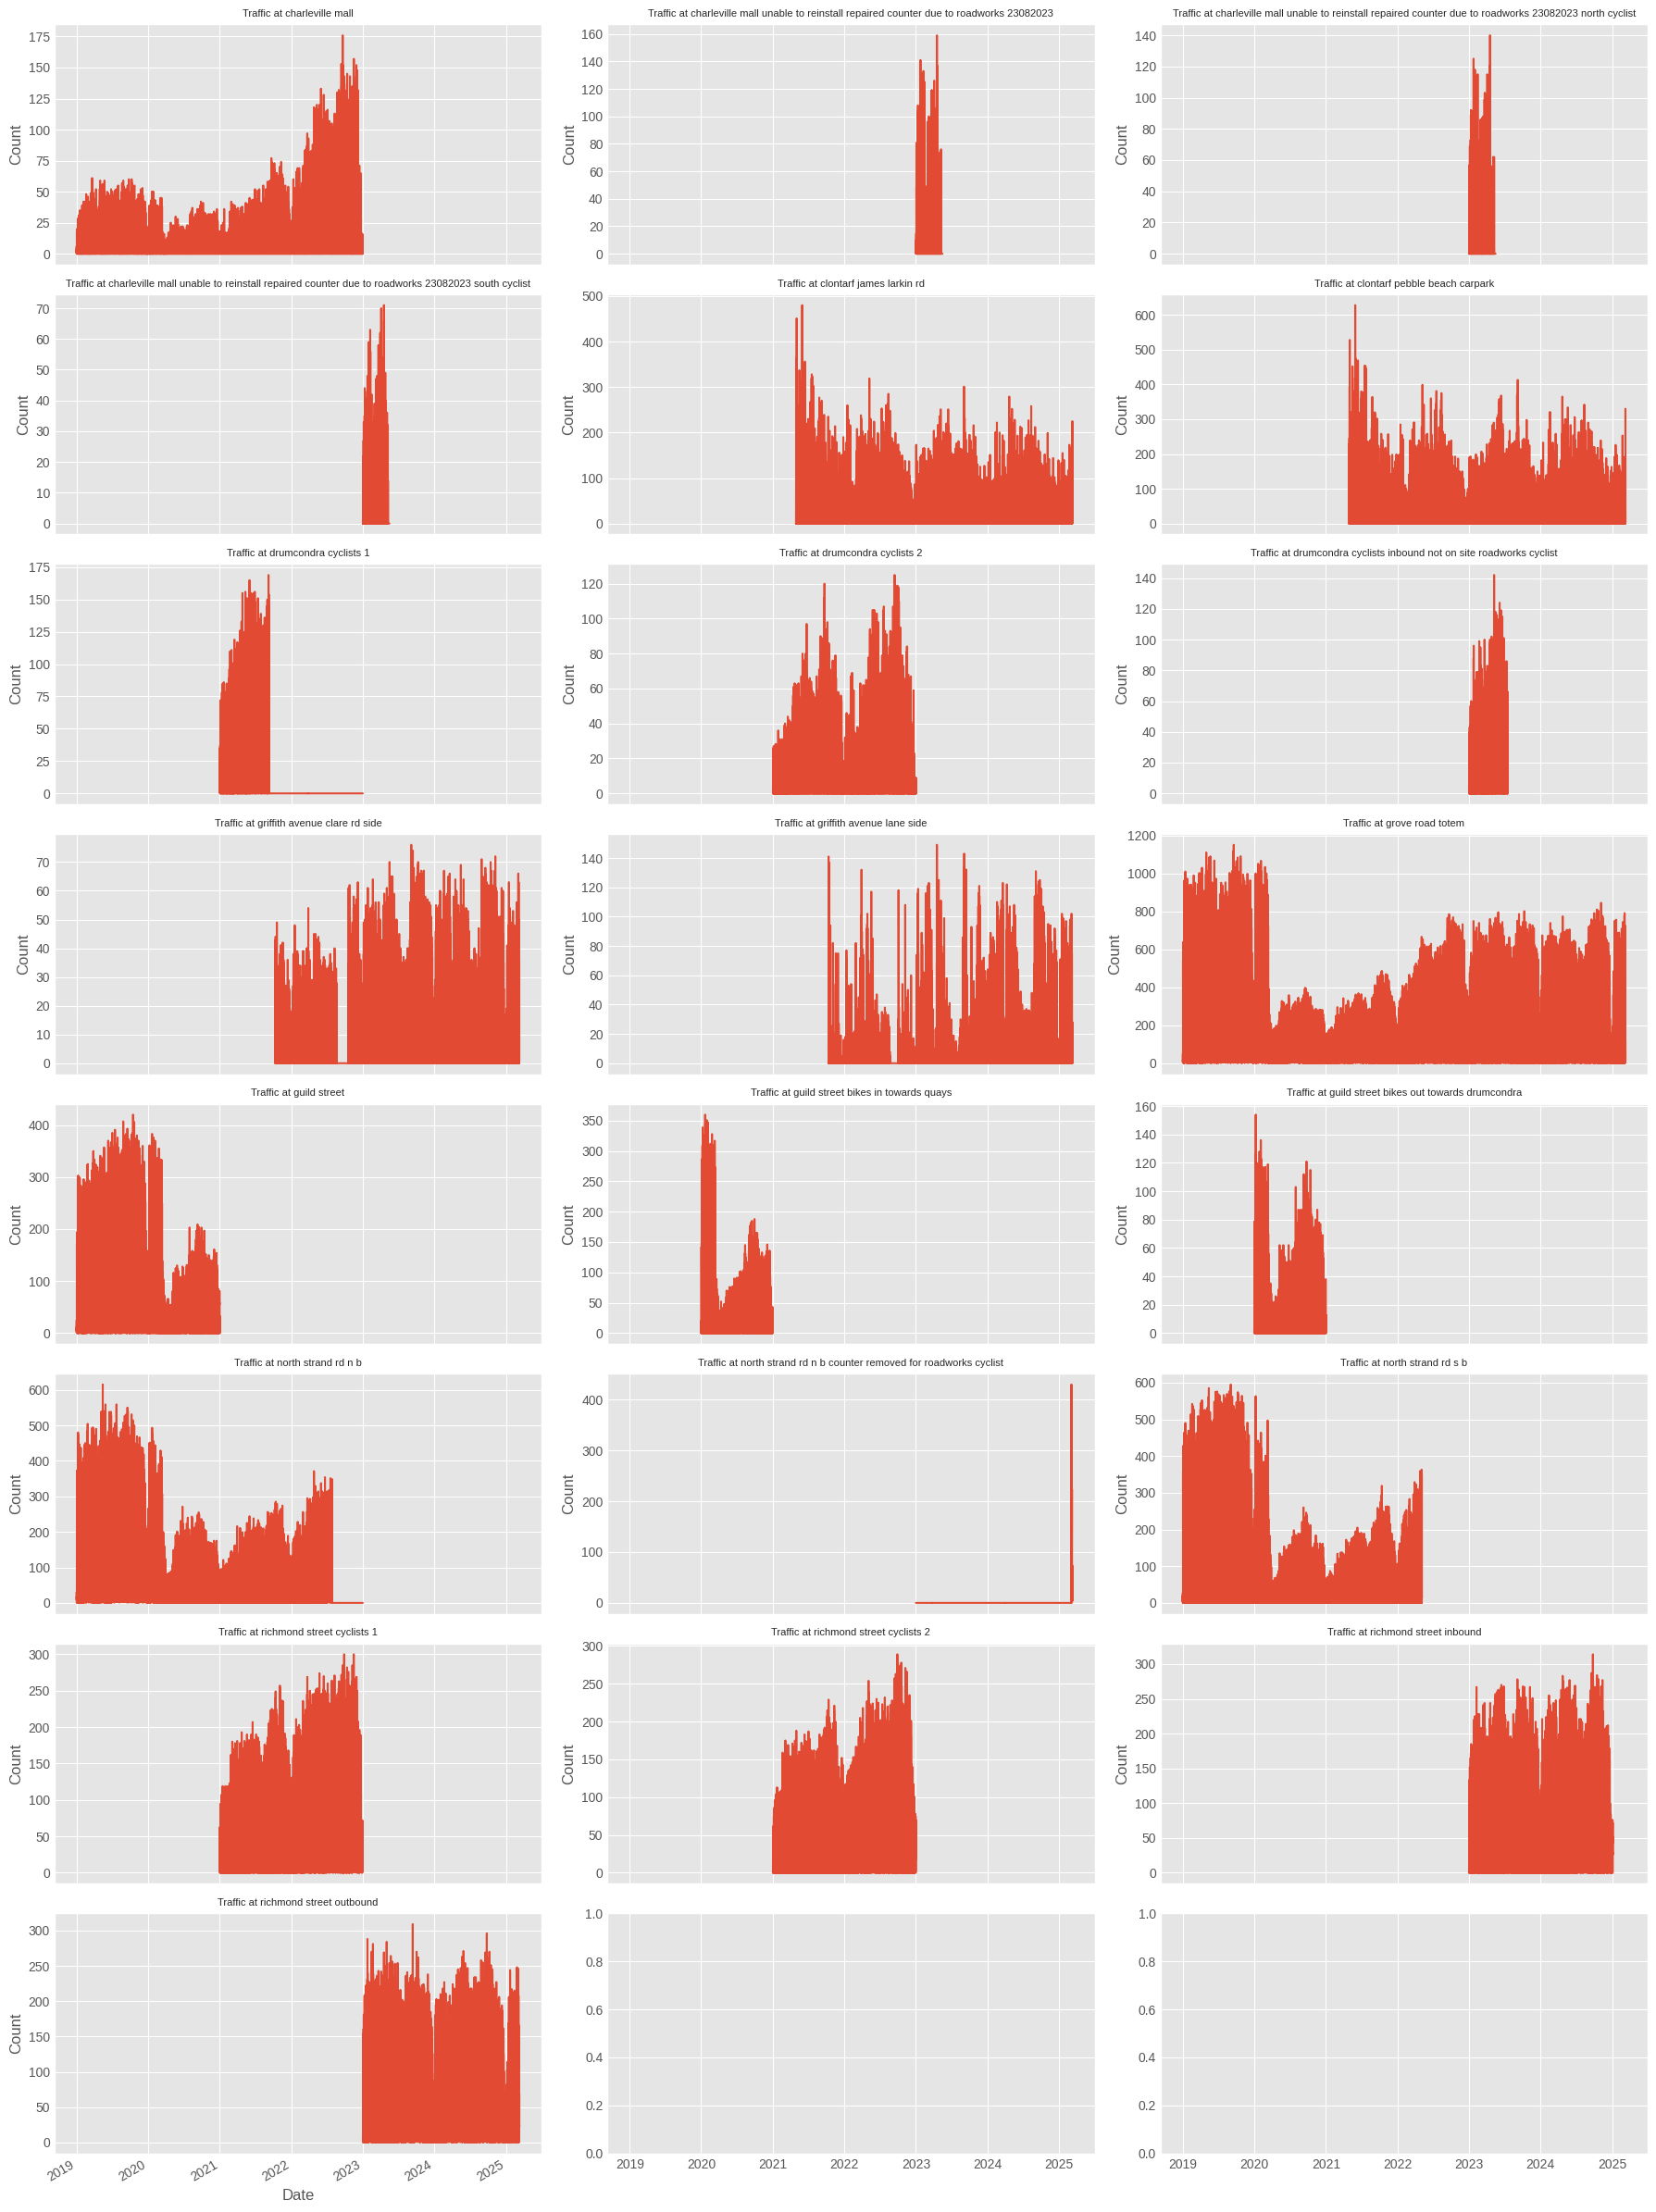

In [ ]:
# Time components
time_components = extract_time_components(cycle)

# Merging footfall and time components datatframes
cycle = pd.concat([cycle, time_components], axis=1)

# First view of cycle count per street
plot_time_series_grid(cycle)

In [ ]:
# Merge columns manually with dictionary
def merge_columns(data, merge_dict):
    data = data.copy()
    for new_col, columns_to_merge in merge_dict.items():
        valid_cols = [col for col in columns_to_merge if col in data.columns]
        if not valid_cols:
            continue
        # Assign higher value from columns
        data[new_col] = data[valid_cols].max(axis=1, skipna=True)
        # Drop original columns
        data.drop(columns=valid_cols, inplace=True)
    return data

# Interpolation of numerical columns for missing values
def interpolation(data):
    data_interpolated = data.copy()
    numeric_cols = data.select_dtypes(include=["number"]).columns
    for col in numeric_cols:
        if data[col].isna().any():
            data_interpolated[col] = data_interpolated[col].interpolate(method="linear", limit_direction="both") # Interpolate linearly
            data_interpolated[col] = data_interpolated[col].fillna(0) # Fill remaining missing values with 0
    return data_interpolated

In [ ]:
cycle.columns

Index(['charleville mall',
       'charleville mall unable to reinstall repaired counter due to roadworks 23082023',
       'charleville mall unable to reinstall repaired counter due to roadworks 23082023 north cyclist',
       'charleville mall unable to reinstall repaired counter due to roadworks 23082023 south cyclist',
       'clontarf james larkin rd', 'clontarf pebble beach carpark',
       'date and time', 'drumcondra cyclists 1', 'drumcondra cyclists 2',
       'drumcondra cyclists inbound not on site roadworks cyclist',
       'griffith avenue clare rd side', 'griffith avenue lane side',
       'grove road totem', 'guild street',
       'guild street bikes in towards quays',
       'guild street bikes out towards drumcondra', 'north strand rd n b',
       'north strand rd n b counter removed for roadworks cyclist',
       'north strand rd s b', 'richmond street cyclists 1',
       'richmond street cyclists 2', 'richmond street inbound',
       'richmond street outbound', 'hour

In [ ]:
# Drop the three specified columns
cycle = cycle.drop(columns=[
    "charleville mall",
    "charleville mall unable to reinstall repaired counter due to roadworks 23082023 north cyclist",
    "charleville mall unable to reinstall repaired counter due to roadworks 23082023 south cyclist",
    "guild street bikes in towards quays",
    "guild street bikes out towards drumcondra",
    "north strand rd n b counter removed for roadworks cyclist"
], axis=1)

merge_dict = {
    "richmond street cyclists 1 merged" : ["richmond street cyclists 1" , "richmond street inbound"],
    "richmond street cyclists 2 merged" : ["richmond street cyclists 2", "richmond street outbound"]
}

cycle = merge_columns(cycle, merge_dict)
cycle.head()

,charleville mall unable to reinstall repaired counter due to roadworks 23082023,clontarf james larkin rd,clontarf pebble beach carpark,date and time,drumcondra cyclists 1,drumcondra cyclists 2,drumcondra cyclists inbound not on site roadworks cyclist,griffith avenue clare rd side,griffith avenue lane side,grove road totem,guild street,north strand rd n b,north strand rd s b,hour,weekday,month,year,richmond street cyclists 1 merged,richmond street cyclists 2 merged
0,NaN,3.0,7.0,2025-01-01 00:00:00,NaN,NaN,NaN,0.0,2.0,12.0,NaN,NaN,NaN,0,2,1,2025,9.0,5.0
1,NaN,2.0,2.0,2025-01-01 01:00:00,NaN,NaN,NaN,1.0,0.0,17.0,NaN,NaN,NaN,1,2,1,2025,1.0,1.0
2,NaN,0.0,1.0,2025-01-01 02:00:00,NaN,NaN,NaN,0.0,0.0,19.0,NaN,NaN,NaN,2,2,1,2025,3.0,15.0
3,NaN,0.0,1.0,2025-01-01 03:00:00,NaN,NaN,NaN,2.0,0.0,7.0,NaN,NaN,NaN,3,2,1,2025,3.0,12.0
4,NaN,0.0,1.0,2025-01-01 04:00:00,NaN,NaN,NaN,1.0,0.0,5.0,NaN,NaN,NaN,4,2,1,2025,1.0,6.0


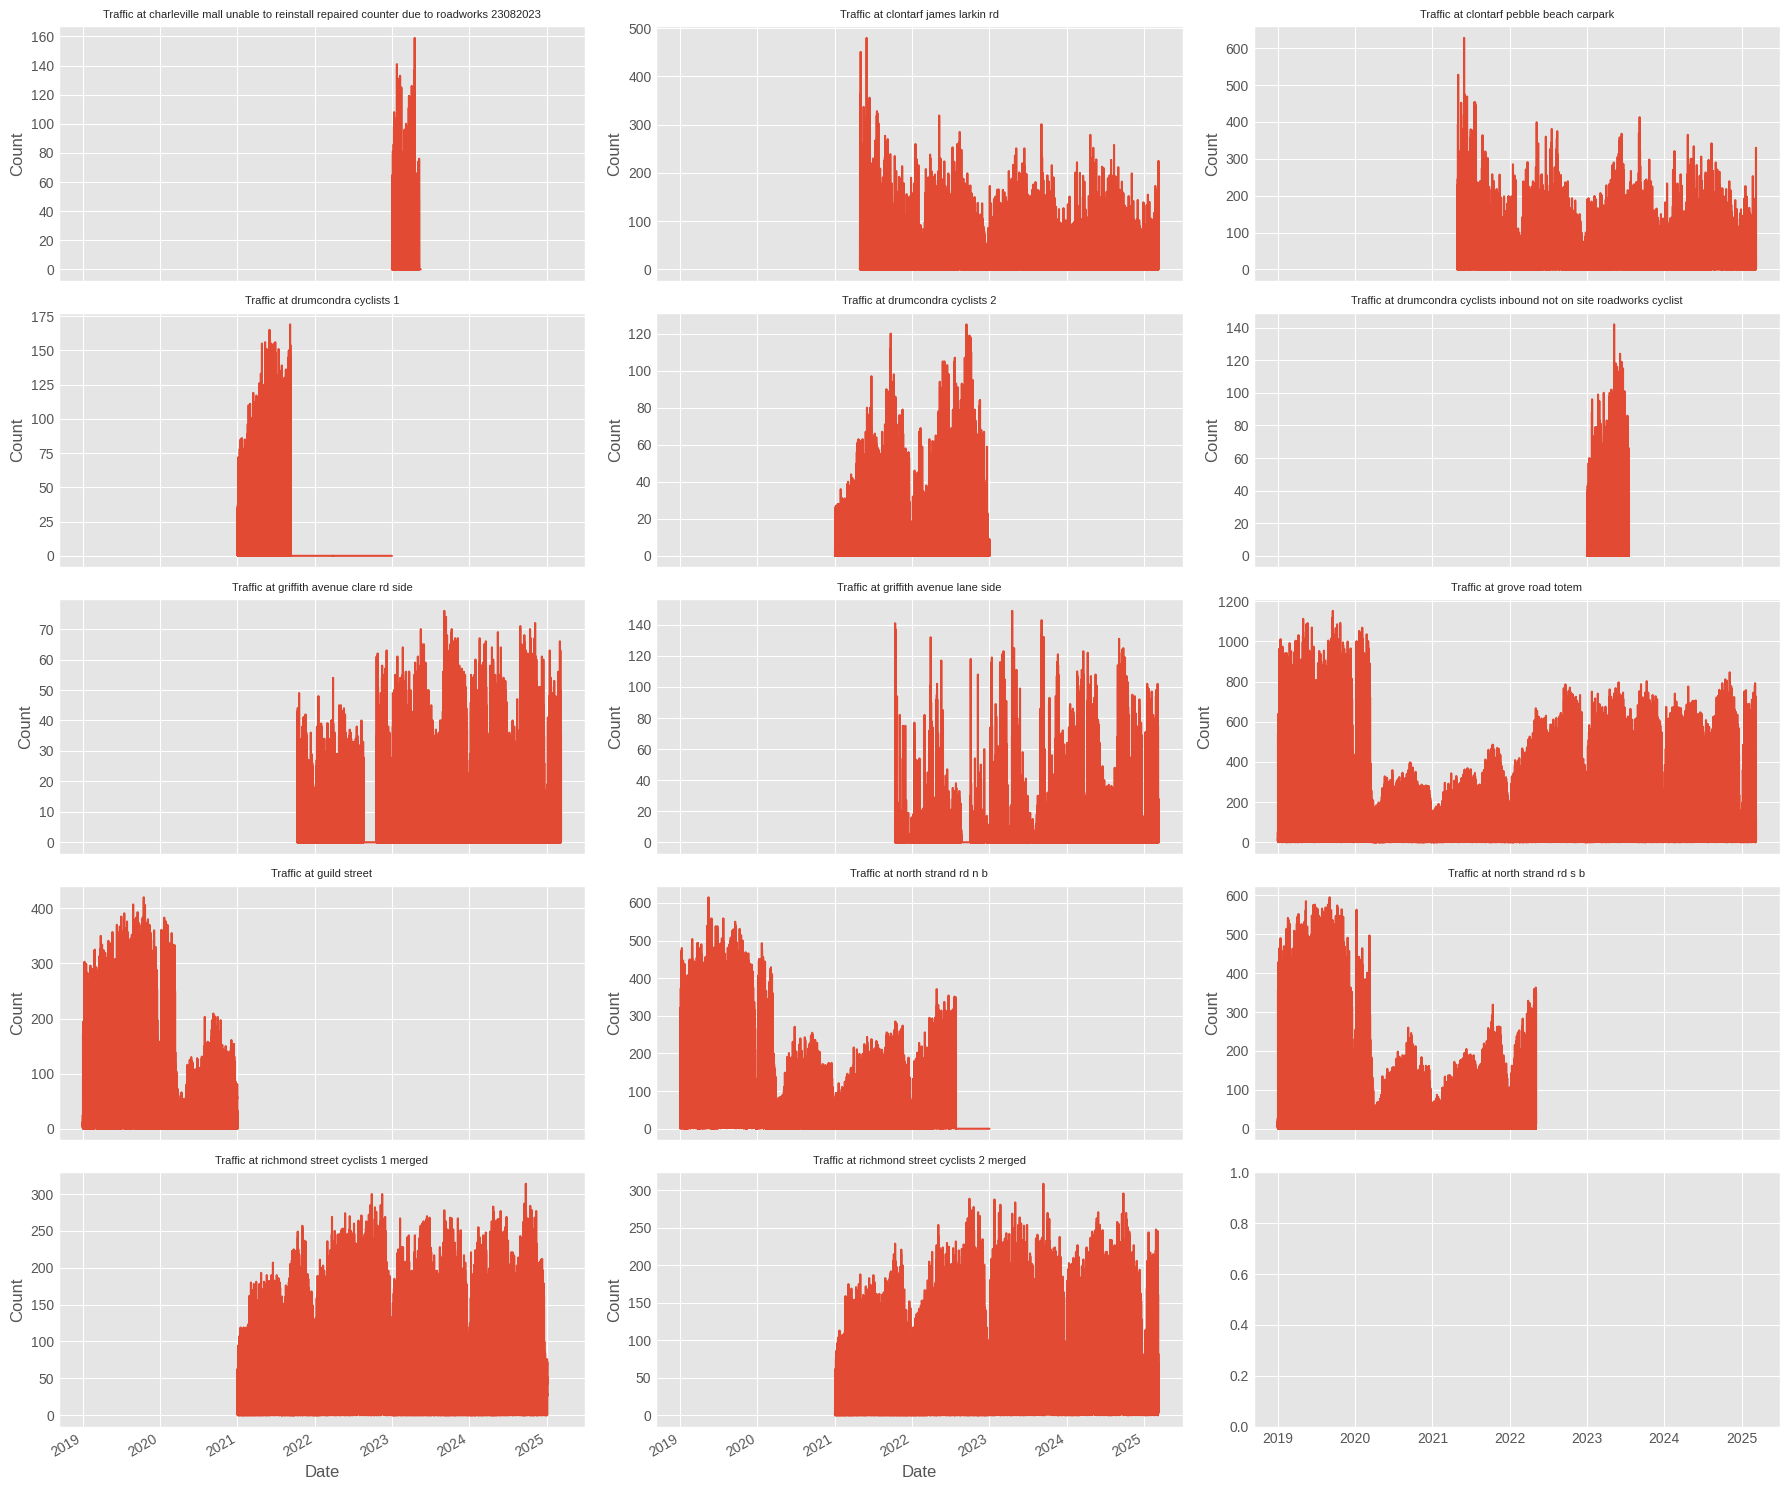

In [ ]:
plot_time_series_grid(cycle)

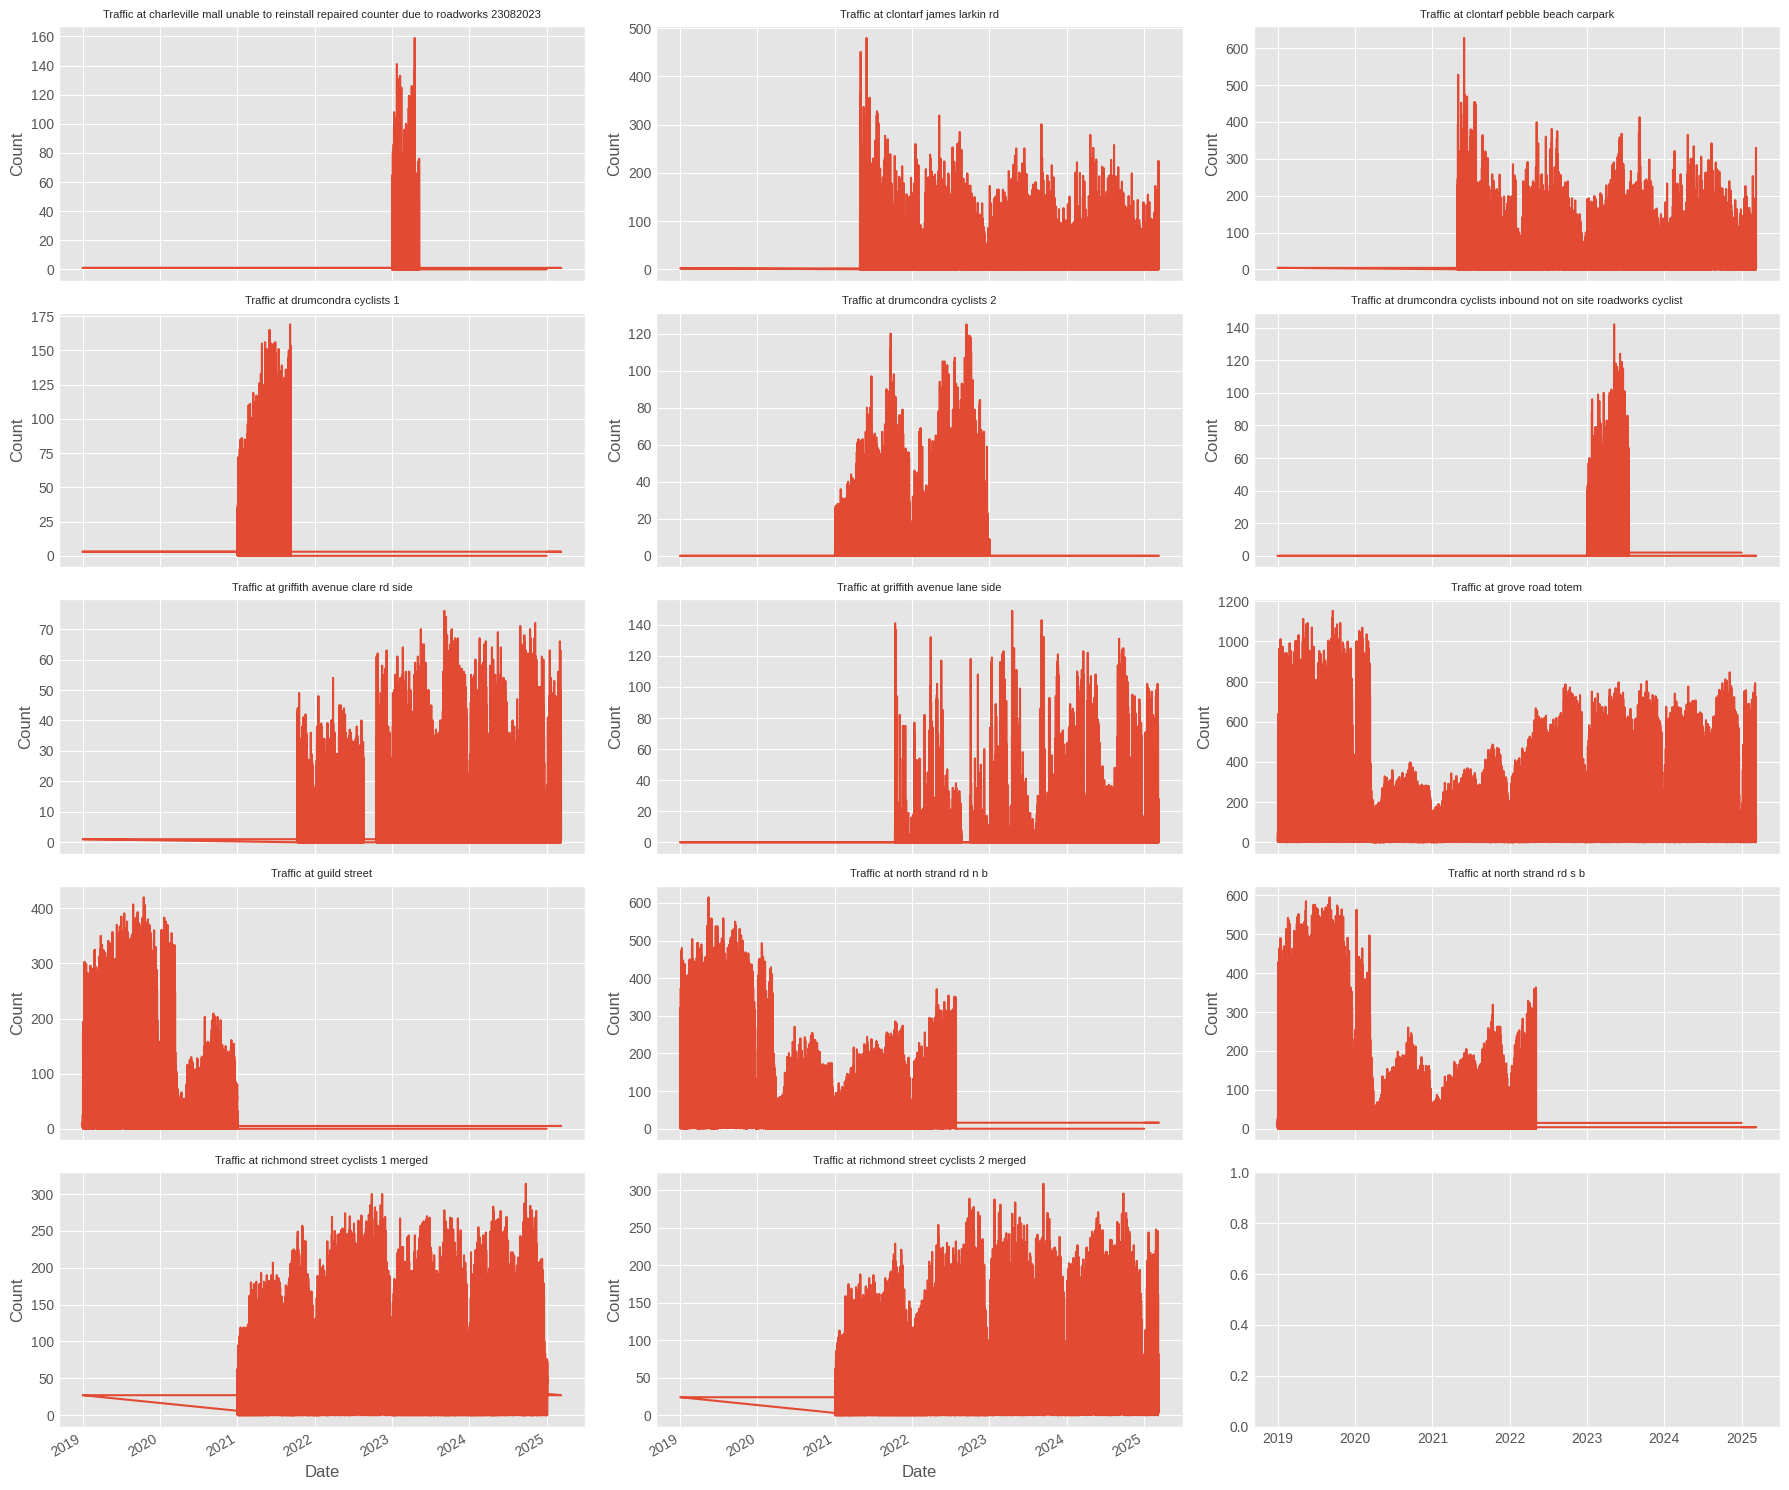

In [ ]:
# Cycle count interpolated
cycle_int = cycle.copy()
cycle_int = interpolation(cycle_int)
plot_time_series_grid(cycle_int)

### **ORDER COLUMNS AND FILL NA TO PROCEED TO EDA**

In [ ]:
def order_cols(data, datetime_col="date and time"):
    # Get all columns except the datetime column
    other_cols = [col for col in data.columns if col != datetime_col]
    # Sort other columns alphabetically
    other_cols_sorted = sorted(other_cols)
    # Create new column order with datetime_col first
    new_order = [datetime_col] + other_cols_sorted
    # Reorder dataframe columns
    data = data[new_order]
    # Fill NaNs with 0 inplace
    data.fillna(value=0, inplace=True)
    return data

cycle = order_cols(cycle)
print(cycle.shape)
cycle.head()

(54239, 19)


,date and time,charleville mall unable to reinstall repaired counter due to roadworks 23082023,clontarf james larkin rd,clontarf pebble beach carpark,drumcondra cyclists 1,drumcondra cyclists 2,drumcondra cyclists inbound not on site roadworks cyclist,griffith avenue clare rd side,griffith avenue lane side,grove road totem,guild street,hour,month,north strand rd n b,north strand rd s b,richmond street cyclists 1 merged,richmond street cyclists 2 merged,weekday,year
0,2025-01-01 00:00:00,0.0,3.0,7.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0,1,0.0,0.0,9.0,5.0,2,2025
1,2025-01-01 01:00:00,0.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,17.0,0.0,1,1,0.0,0.0,1.0,1.0,2,2025
2,2025-01-01 02:00:00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,2,1,0.0,0.0,3.0,15.0,2,2025
3,2025-01-01 03:00:00,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,7.0,0.0,3,1,0.0,0.0,3.0,12.0,2,2025
4,2025-01-01 04:00:00,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,5.0,0.0,4,1,0.0,0.0,1.0,6.0,2,2025


## **EXPLORATORY DATA ANALYSIS**

### **DESCRIPTIVE STATISTICS**

In [ ]:
cycle.describe()

,date and time,charleville mall unable to reinstall repaired counter due to roadworks 23082023,clontarf james larkin rd,clontarf pebble beach carpark,drumcondra cyclists 1,drumcondra cyclists 2,drumcondra cyclists inbound not on site roadworks cyclist,griffith avenue clare rd side,griffith avenue lane side,grove road totem,guild street,hour,month,north strand rd n b,north strand rd s b,richmond street cyclists 1 merged,richmond street cyclists 2 merged,weekday,year
count,54239,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000,54239.000000
mean,2022-02-03 23:57:38.360220672,0.739708,24.294640,33.396357,3.735781,2.755047,0.827965,5.479470,2.835248,108.431571,15.198695,11.500249,6.376168,26.656594,21.117038,33.187190,33.831358,3.001272,2021.605800
min,2019-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2019.000000
25%,2020-07-19 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,0.000000,6.000000,3.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2020.000000
50%,2022-02-04 00:00:00,0.000000,2.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,81.000000,0.000000,12.000000,6.000000,4.000000,1.000000,9.000000,12.000000,3.000000,2022.000000
75%,2023-08-22 23:30:00,0.000000,38.000000,52.000000,0.000000,1.000000,0.000000,8.000000,2.000000,133.000000,8.000000,17.500000,9.000000,35.000000,29.000000,61.000000,59.000000,5.000000,2023.000000
max,2025-03-09 23:00:00,159.000000,480.000000,628.000000,169.000000,125.000000,142.000000,76.000000,149.000000,1152.000000,420.000000,23.000000,12.000000,615.000000,595.000000,314.000000,309.000000,6.000000,2025.000000
std,NaN,5.142917,40.265458,54.884128,14.604894,8.022434,5.170552,9.616511,8.142158,123.443129,38.423839,6.922087,3.498220,52.000050,46.576143,44.424341,43.652547,1.999442,1.785352


### **HANDLING MISSING VALUES**

In [ ]:
# Check for any remaining missing values
print(f"Missing values: {cycle.isnull().sum().sum()}")

Missing values: 0


In [ ]:
# Prefix CYC
def add_prefix_to_columns(data, prefix="CYC_", exclude_col="date and time"):
    data = data.copy()

    for col in ["date", "Date And time"]:
        if col in data.columns:
            data.rename(columns={col: exclude_col}, inplace=True)

    exclude_cols = [exclude_col, "weekday", "day", "hour", "month", "year"]

    data.rename(columns={
        col: col.title() for col in data.columns if col not in exclude_cols
    }, inplace=True)

    data.rename(columns={
        col: f"{prefix}{col}" for col in data.columns if col not in exclude_cols
    }, inplace=True)

    return data

In [ ]:
cycle = add_prefix_to_columns(cycle)

In [ ]:
cycle.head()

,date and time,CYC_Charleville Mall Unable To Reinstall Repaired Counter Due To Roadworks 23082023,CYC_Clontarf James Larkin Rd,CYC_Clontarf Pebble Beach Carpark,CYC_Drumcondra Cyclists 1,CYC_Drumcondra Cyclists 2,CYC_Drumcondra Cyclists Inbound Not On Site Roadworks Cyclist,CYC_Griffith Avenue Clare Rd Side,CYC_Griffith Avenue Lane Side,CYC_Grove Road Totem,CYC_Guild Street,hour,month,CYC_North Strand Rd N B,CYC_North Strand Rd S B,CYC_Richmond Street Cyclists 1 Merged,CYC_Richmond Street Cyclists 2 Merged,weekday,year
0,2025-01-01 00:00:00,0.0,3.0,7.0,0.0,0.0,0.0,0.0,2.0,12.0,0.0,0,1,0.0,0.0,9.0,5.0,2,2025
1,2025-01-01 01:00:00,0.0,2.0,2.0,0.0,0.0,0.0,1.0,0.0,17.0,0.0,1,1,0.0,0.0,1.0,1.0,2,2025
2,2025-01-01 02:00:00,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,19.0,0.0,2,1,0.0,0.0,3.0,15.0,2,2025
3,2025-01-01 03:00:00,0.0,0.0,1.0,0.0,0.0,0.0,2.0,0.0,7.0,0.0,3,1,0.0,0.0,3.0,12.0,2,2025
4,2025-01-01 04:00:00,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,5.0,0.0,4,1,0.0,0.0,1.0,6.0,2,2025


In [ ]:
# Filter data from 01-01-2019 for study purposes
cycle = cycle[cycle["date and time"] >= "2019-01-01"]
cycle.head()

# Percentage of 0 values per column
zero_percent = (cycle == 0).sum() / len(cycle) * 100
print("Percentage of 0 values per column:")
print(zero_percent.sort_values(ascending=False))

# Identify columns with over 45% zeros and names starting with 'CYC'
columns_to_drop = [
    col for col in cycle.columns
    if zero_percent[col] > 45 and col.startswith("CYC_")
]

# Drop those columns
cycle.drop(columns=columns_to_drop, inplace=True)

print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop} from the dataset")

Percentage of 0 values per column:
CYC_Charleville Mall Unable To Reinstall Repaired Counter Due To Roadworks 23082023    94.970409
CYC_Drumcondra Cyclists Inbound Not On Site Roadworks Cyclist                          92.599421
CYC_Drumcondra Cyclists 1                                                              89.415365
CYC_Drumcondra Cyclists 2                                                              72.864544
CYC_Guild Street                                                                       68.919043
CYC_Griffith Avenue Lane Side                                                          68.253471
CYC_Griffith Avenue Clare Rd Side                                                      55.504342
CYC_North Strand Rd S B                                                                48.575748
CYC_North Strand Rd N B                                                                43.708402
CYC_Clontarf James Larkin Rd                                                           42.94

In [ ]:
cycle.head()

,date and time,CYC_Clontarf James Larkin Rd,CYC_Clontarf Pebble Beach Carpark,CYC_Grove Road Totem,hour,month,CYC_North Strand Rd N B,CYC_Richmond Street Cyclists 1 Merged,CYC_Richmond Street Cyclists 2 Merged,weekday,year
0,2025-01-01 00:00:00,3.0,7.0,12.0,0,1,0.0,9.0,5.0,2,2025
1,2025-01-01 01:00:00,2.0,2.0,17.0,1,1,0.0,1.0,1.0,2,2025
2,2025-01-01 02:00:00,0.0,1.0,19.0,2,1,0.0,3.0,15.0,2,2025
3,2025-01-01 03:00:00,0.0,1.0,7.0,3,1,0.0,3.0,12.0,2,2025
4,2025-01-01 04:00:00,0.0,1.0,5.0,4,1,0.0,1.0,6.0,2,2025


### **TIME COMPONENTS**

In [ ]:
def extract_time_components(data):
    return pd.DataFrame({
        "hour": data["date and time"].dt.hour,
        "weekday": data["date and time"].dt.dayofweek,
        "month": data["date and time"].dt.month,
        "year": data["date and time"].dt.year,
    })

def extract_time_patterns(data):
    hourly = data.groupby("hour").mean(numeric_only=True)
    weekly = data.groupby("weekday").mean(numeric_only=True)
    monthly = data.groupby("month").mean(numeric_only=True)
    yearly = data.groupby("year").mean(numeric_only=True)
    return {
        "hourly": hourly,
        "weekly": weekly,
        "monthly": monthly,
        "yearly": yearly
    }

In [ ]:
# Time components
time_components = extract_time_components(cycle)

# Patterns
patterns = extract_time_patterns(cycle)

# Results
hourly_p= patterns["hourly"]
weekly_p = patterns["weekly"]
monthly_p = patterns["monthly"]
yearly_p = patterns["yearly"]

In [ ]:
cycle.head()

,date and time,CYC_Clontarf James Larkin Rd,CYC_Clontarf Pebble Beach Carpark,CYC_Grove Road Totem,hour,month,CYC_North Strand Rd N B,CYC_Richmond Street Cyclists 1 Merged,CYC_Richmond Street Cyclists 2 Merged,weekday,year
0,2025-01-01 00:00:00,3.0,7.0,12.0,0,1,0.0,9.0,5.0,2,2025
1,2025-01-01 01:00:00,2.0,2.0,17.0,1,1,0.0,1.0,1.0,2,2025
2,2025-01-01 02:00:00,0.0,1.0,19.0,2,1,0.0,3.0,15.0,2,2025
3,2025-01-01 03:00:00,0.0,1.0,7.0,3,1,0.0,3.0,12.0,2,2025
4,2025-01-01 04:00:00,0.0,1.0,5.0,4,1,0.0,1.0,6.0,2,2025


### **TREND CHARTS**

In [ ]:
def set_plot_style():
    style_options = [
        "seaborn-v0_8-whitegrid",
        "seaborn-whitegrid",
        "ggplot"
    ]
    for style in style_options:
        try:
            plt.style.use(style)
            print(f"Using style: {style}")
            return style
        except OSError:
            continue
    # If all styles fail, use the default style
    print("All specified styles failed. Using default matplotlib style.")
    plt.style.use('default')
    return 'default'


def plot_patterns(data, exclude_cols, x_label, title, x_ticks, x_tick_labels=None, peak_label_prefix="Peak", figsize=(10, 8), color_palette=None, save_path=None):
    # Set the plot style
    set_plot_style()

    # Filter columns by location
    location_columns = [col for col in data.columns if col not in exclude_cols]

    # Calculate average counts for sorting legend
    avg_counts = {col: data[col].mean() for col in location_columns}

    # Sort location columns by average count descending (highest to lowest)
    sorted_columns = sorted(avg_counts, key=avg_counts.get, reverse=True)

    # Set color palette
    if color_palette:
        sns.set_palette(color_palette)

    # Plot with sorted columns
    fig, ax = plt.subplots(figsize=figsize)
    data[sorted_columns].plot(kind="line", marker="o", ax=ax)

    plt.title(title, fontsize=20)
    plt.xlabel(x_label, fontsize=14)
    plt.ylabel("Average Count", fontsize=14)
    plt.xticks(x_ticks, x_tick_labels)
    plt.grid(True, alpha=0.3)

    # Legend is already sorted by traffic volume since we plotted sorted_columns
    ax.legend(title="Location", loc="upper right", frameon=True)

    # Highlight peak
    peak_index = data[location_columns].mean(axis=1).idxmax()
    if x_tick_labels and peak_index <= len(x_tick_labels):
        peak_label = f"{peak_label_prefix}: {x_tick_labels[peak_index-1]}"
    else:
        peak_label = f"{peak_label_prefix}: {peak_index}"

    plt.axvline(x=peak_index, color="red", linestyle="--", alpha=0.7, label=peak_label)

    plt.tight_layout()
    plt.show()

    return fig, ax


# Convenience wrapper functions for specific use cases
def plot_hourly_patterns(data, **kwargs):
    return plot_patterns(
        data=data,
        exclude_cols=kwargs.get("exclude_cols", ["year", "month", "weekday"]),
        x_label="Hour",
        title=kwargs.get("title", "Average Hourly Cyclist Traffic by Location"),
        x_ticks=range(0, 24),
        peak_label_prefix="Peak Hour",
        **{k: v for k, v in kwargs.items() if k not in ["exclude_cols", "title"]}
    )

# Monthrly patterns
def plot_monthly_patterns(data, **kwargs):
    month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    return plot_patterns(
        data=data,
        exclude_cols=kwargs.get("exclude_cols", ["year", "weekday", "hour"]),
        x_label="Month",
        title=kwargs.get("title", "Average Monthly Cyclist Traffic by Location"),
        x_ticks=range(1, 13),
        x_tick_labels=month_names,
        peak_label_prefix="Peak Month",
        **{k: v for k, v in kwargs.items() if k not in ["exclude_cols", "title"]}
    )


### **HOURLY TRENDS**

Using style: seaborn-v0_8-whitegrid


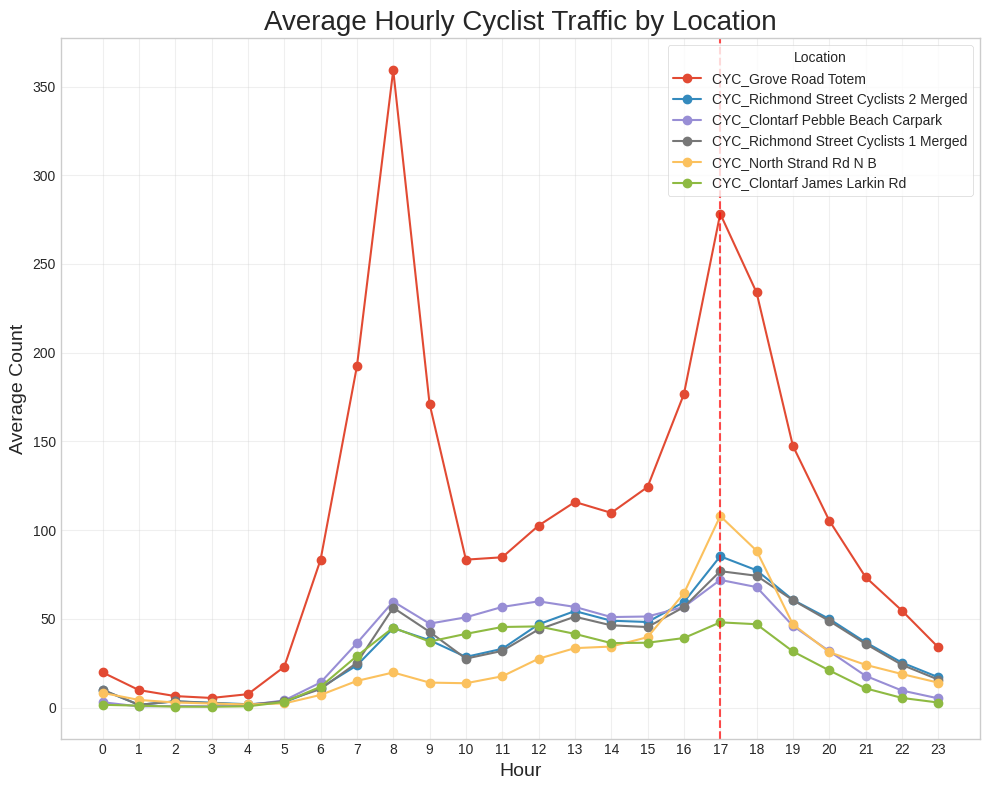

(<Figure size 1000x800 with 1 Axes>,
 <Axes: title={'center': 'Average Hourly Cyclist Traffic by Location'}, xlabel='Hour', ylabel='Average Count'>)

In [ ]:
plot_hourly_patterns(hourly_p)

Overall, there are two times a day when the number of cyclist reaches its peaks, at 8:00 and 17:00.

The cyclist traffic indicates Grove Road is the busiest location in Dublin within the counters in the dataset. Followed by Richmond Street Cyclist point 2 and Clontarf Pebble Beach carpak. Considering cyclists traffic depends on the infrastructure built to cyclist rides, and Grove Road is next to a canal and infrastructure could influence this output.

### **MONTHLY TRENDS**

Using style: seaborn-v0_8-whitegrid


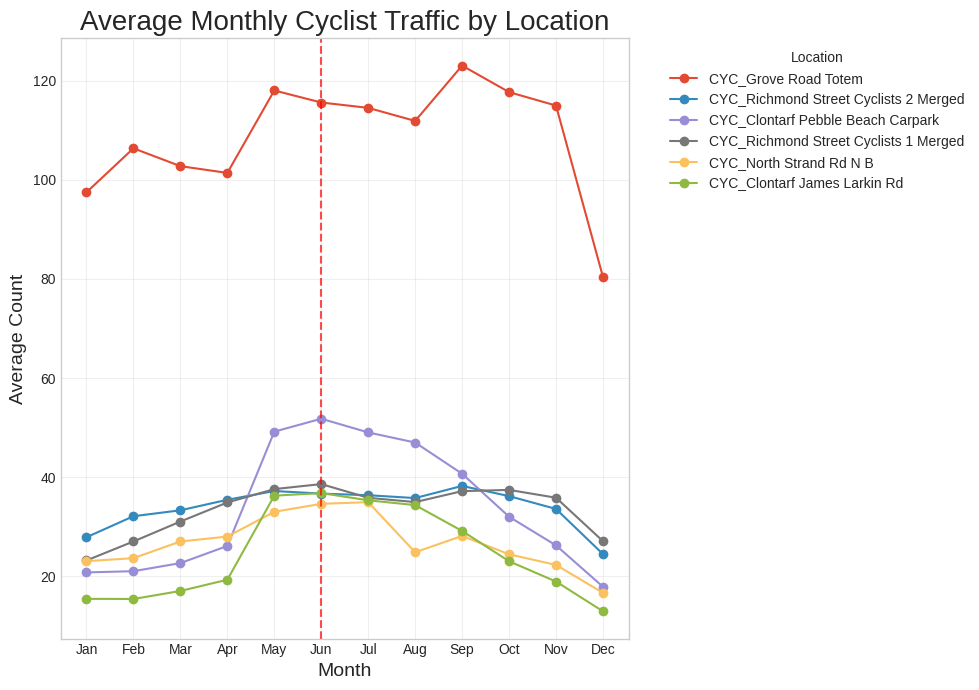

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Average Monthly Cyclist Traffic by Location'}, xlabel='Month', ylabel='Average Count'>)

In [ ]:
plot_monthly_patterns(monthly_p)

The monthly behaviour of cyclist indicates that September is the month with the highest number of cyclist, but in average, June is the month that all locations are considered as busiest.

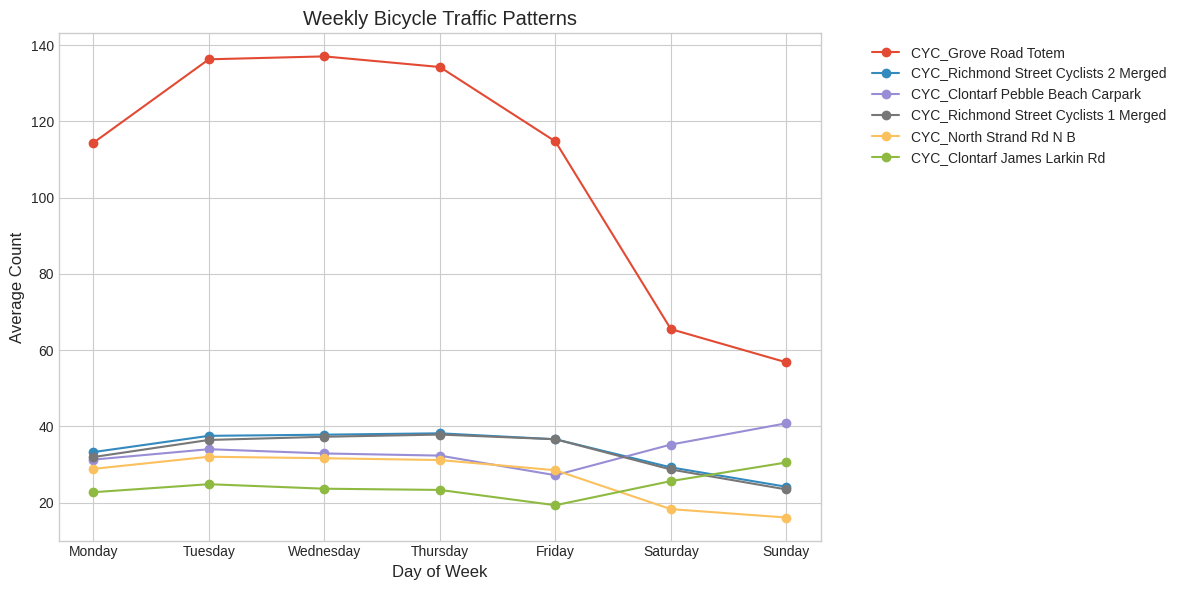

In [ ]:
# Filter non-location columns
location_columns = [col for col in weekly_p.columns if col not in ["year", "month", "weekday", "hour"]]

# Calculate average counts for sorting legend
avg_counts = {col: weekly_p[col].mean() for col in location_columns}

# Sort location columns by average count descending (highest to lowest)
sorted_columns = sorted(avg_counts, key=avg_counts.get, reverse=True)

# Weekly patterns
days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

plt.figure(figsize=(12, 6))
for column in sorted_columns:
    plt.plot(days, weekly_p[column], marker="o", label=column)
plt.title("Weekly Bicycle Traffic Patterns")
plt.xlabel("Day of Week")
plt.ylabel("Average Count")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In a weekly basis, Grove Road cyclist count is high between Monday to Friday, and decreases during the weekend, which could be related to work patterns.

The rest of locations, indicates a consistent number of cyclist from Monday to Friday and a moderate decrease or increase during the weekend.

### **CORRELATION HEATMAP**

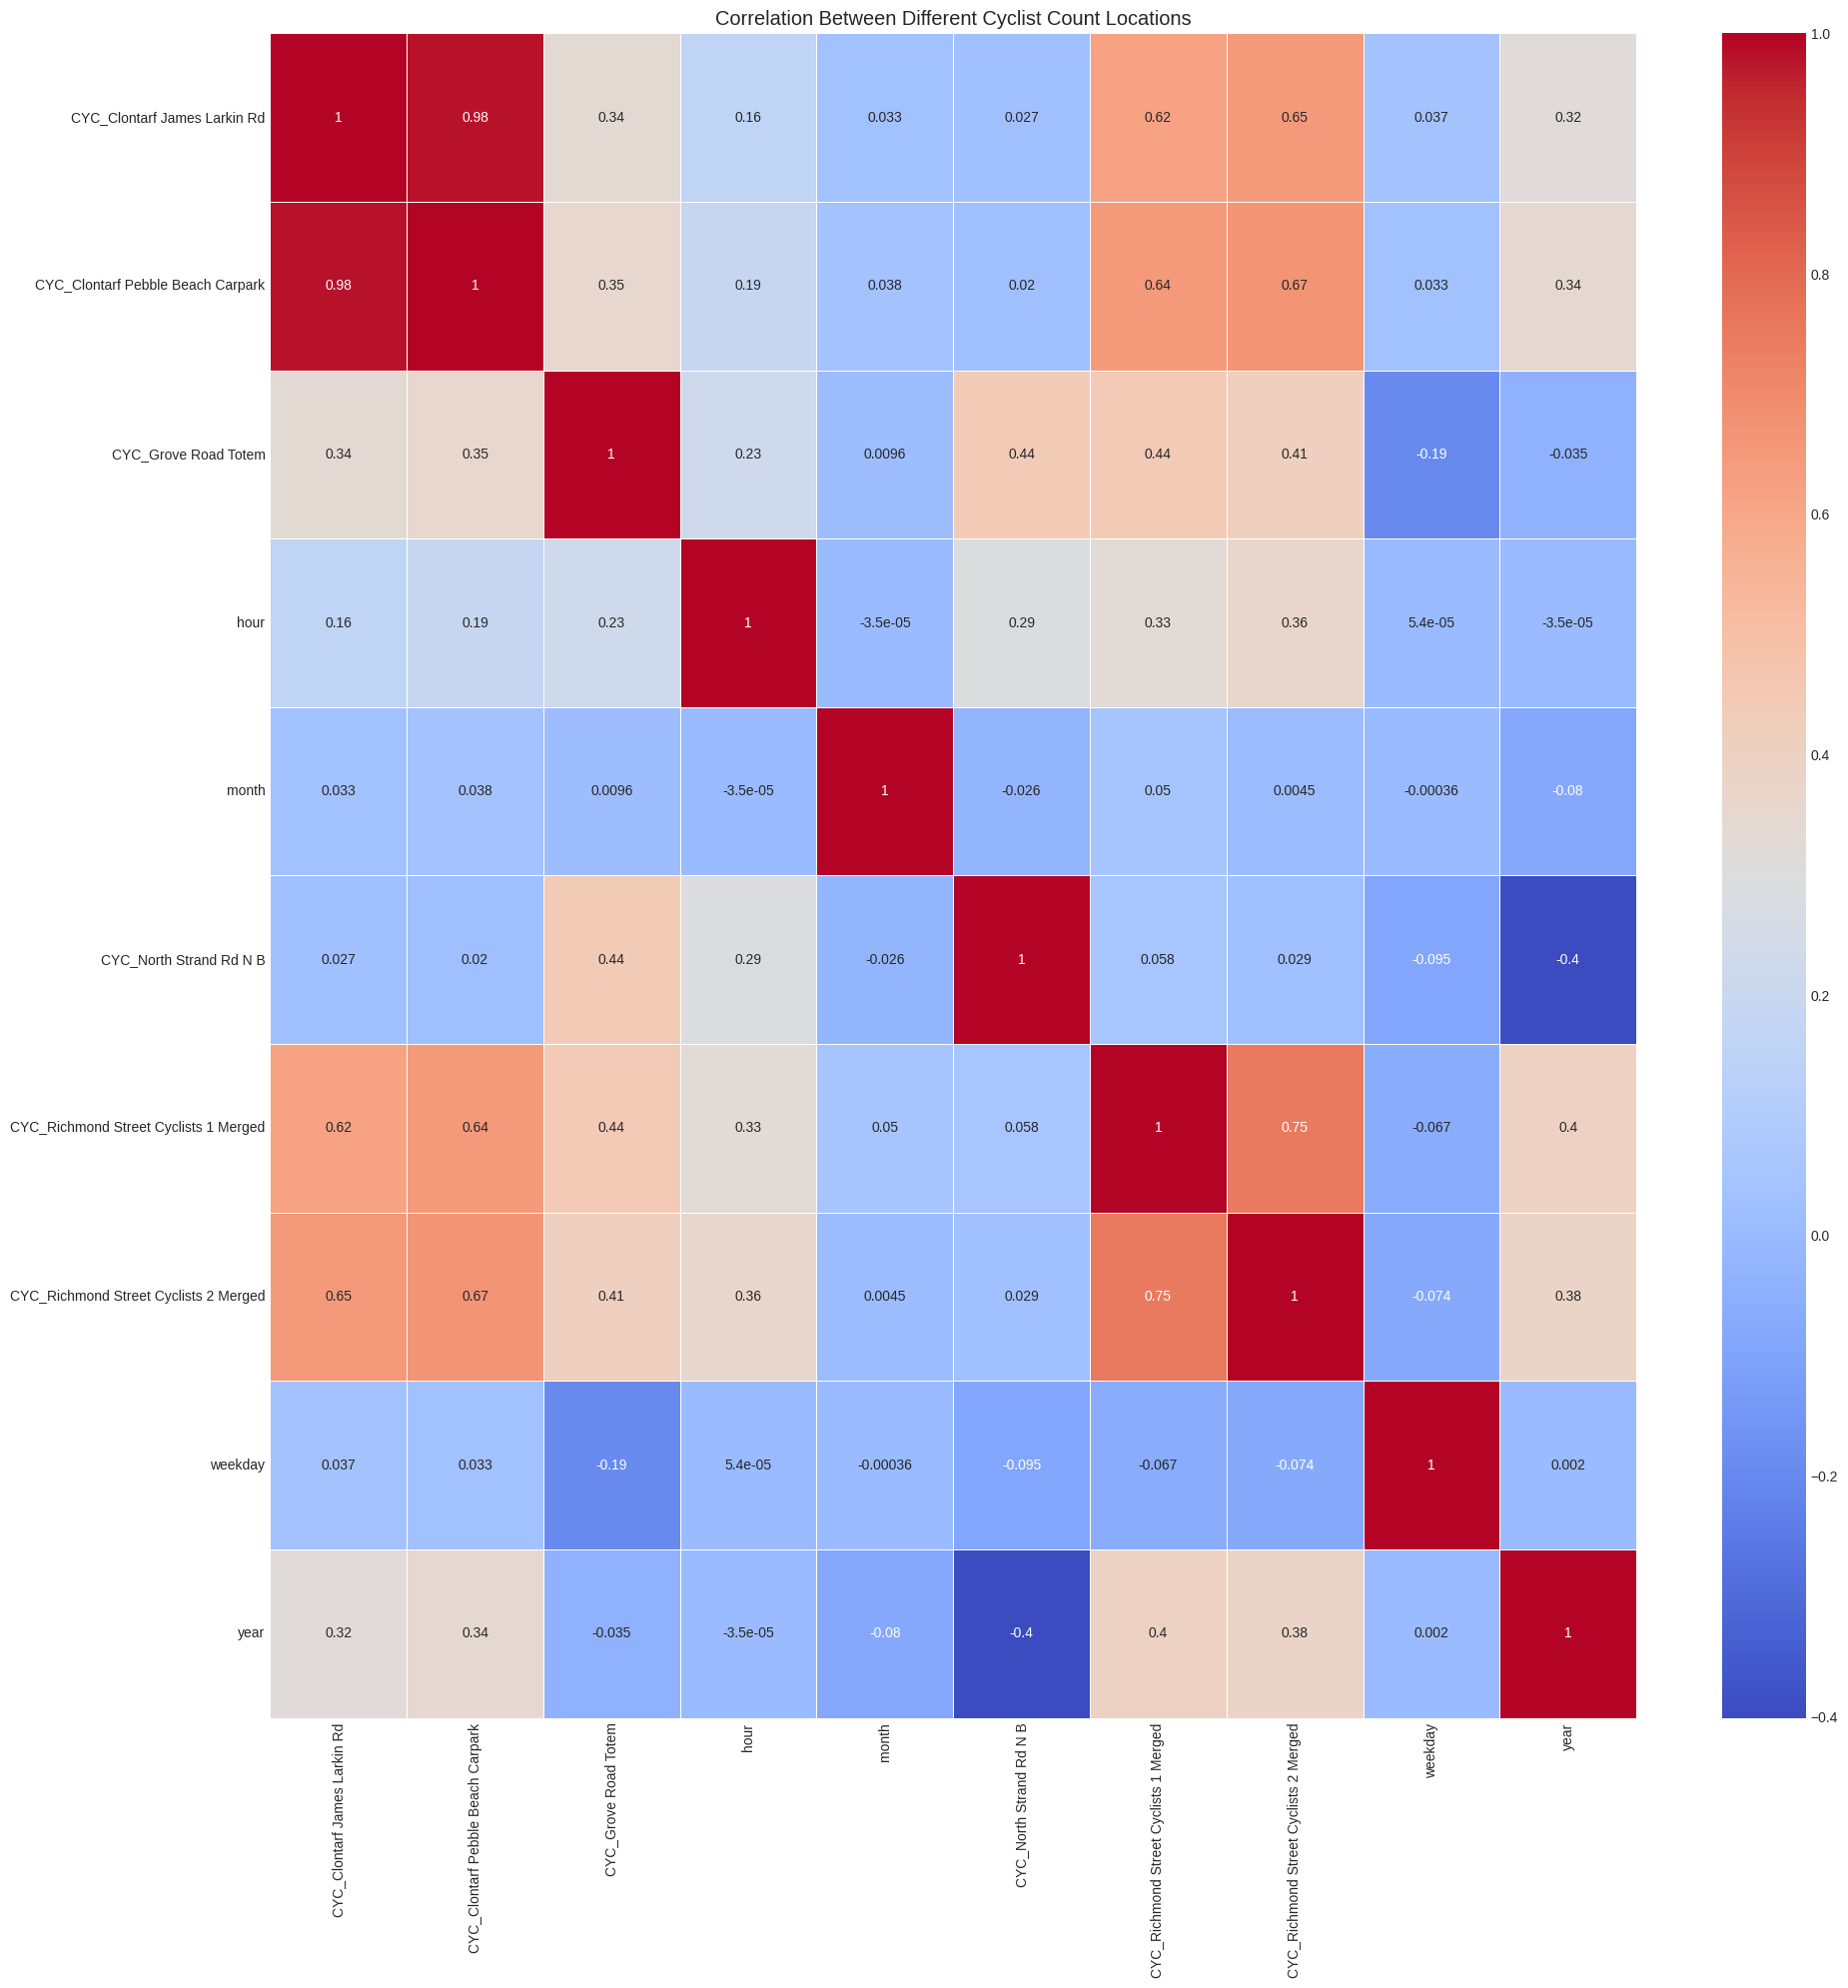

In [ ]:
# Correlation between different locations
plt.figure(figsize=(20, 20))
correlation = cycle.drop(columns=["date and time"]).corr()
sns.heatmap(correlation, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Between Different Cyclist Count Locations")
plt.tight_layout()

In [ ]:
cycle.head()

,date and time,CYC_Clontarf James Larkin Rd,CYC_Clontarf Pebble Beach Carpark,CYC_Grove Road Totem,hour,month,CYC_North Strand Rd N B,CYC_Richmond Street Cyclists 1 Merged,CYC_Richmond Street Cyclists 2 Merged,weekday,year
0,2025-01-01 00:00:00,3.0,7.0,12.0,0,1,0.0,9.0,5.0,2,2025
1,2025-01-01 01:00:00,2.0,2.0,17.0,1,1,0.0,1.0,1.0,2,2025
2,2025-01-01 02:00:00,0.0,1.0,19.0,2,1,0.0,3.0,15.0,2,2025
3,2025-01-01 03:00:00,0.0,1.0,7.0,3,1,0.0,3.0,12.0,2,2025
4,2025-01-01 04:00:00,0.0,1.0,5.0,4,1,0.0,1.0,6.0,2,2025


### **PEAK HOURS**

In [ ]:
# Peak hours
peak_hours = cycle.drop(columns=["date and time"]).groupby("hour").sum().idxmax()
print("Peak traffic hours by location:")
print(peak_hours)
print(peak_hours.value_counts())

# Peak days
peak_days = cycle.drop(columns=["date and time"]).groupby("weekday").sum().idxmax()
print("\nPeak traffic days by location:")
for location, day in peak_days.items():
    print(f"{location}: {days[day]}")
print(peak_days.value_counts())

Peak traffic hours by location:
CYC_Clontarf James Larkin Rd             17
CYC_Clontarf Pebble Beach Carpark        17
CYC_Grove Road Totem                      8
month                                     2
CYC_North Strand Rd N B                  17
CYC_Richmond Street Cyclists 1 Merged    17
CYC_Richmond Street Cyclists 2 Merged    17
weekday                                   2
year                                      2
dtype: int32
17    5
2     3
8     1
Name: count, dtype: int64

Peak traffic days by location:
CYC_Clontarf James Larkin Rd: Sunday
CYC_Clontarf Pebble Beach Carpark: Sunday
CYC_Grove Road Totem: Wednesday
hour: Sunday
month: Tuesday
CYC_North Strand Rd N B: Tuesday
CYC_Richmond Street Cyclists 1 Merged: Thursday
CYC_Richmond Street Cyclists 2 Merged: Thursday
year: Saturday
6    3
1    2
3    2
2    1
5    1
Name: count, dtype: int64


The busiest time for most of locations seems to be during the 08:00 followed by 17:00. And the busiest day seems to be Monday followed by Wednesday. Which could indicate that pedestrian patterns could highly related to work-related times and behaviours.

In [ ]:
columns_to_exclude = ["year", "month", "weekday", "hour"]
location_cols = [col for col in cycle.columns if col not in ["date and time"] + columns_to_exclude]

# Group by day and hour and sum location columns
peak_day_hour = cycle.groupby(["weekday", "hour"])[location_cols].sum()
peak_day_hour_total = peak_day_hour.sum(axis=1)
peak_combination = peak_day_hour_total.idxmax()

# Filter the rows matching the peak day and hour
busiest_rows = cycle[(cycle["weekday"] == peak_combination[0]) &
                       (cycle["hour"] == peak_combination[1])]

#  Specific row
busiest_row_idx = busiest_rows[location_cols].sum(axis=1).idxmax()
busiest_row = cycle.loc[busiest_row_idx]

# Cycle DataFrame
print("\nAs DataFrame:")
cycle.loc[[busiest_row_idx]]


As DataFrame:


,date and time,CYC_Clontarf James Larkin Rd,CYC_Clontarf Pebble Beach Carpark,CYC_Grove Road Totem,hour,month,CYC_North Strand Rd N B,CYC_Richmond Street Cyclists 1 Merged,CYC_Richmond Street Cyclists 2 Merged,weekday,year
32728,2022-07-19 17:00:00,175.0,309.0,412.0,17,7,351.0,231.0,139.0,1,2022


In [ ]:
# Dropping redundant columns
cycle.drop(columns=["hour", "weekday", "month", "year", "is_holiday"], errors="ignore", inplace=True)

In [ ]:
cycle.head()

,date and time,CYC_Clontarf James Larkin Rd,CYC_Clontarf Pebble Beach Carpark,CYC_Grove Road Totem,CYC_North Strand Rd N B,CYC_Richmond Street Cyclists 1 Merged,CYC_Richmond Street Cyclists 2 Merged
0,2025-01-01 00:00:00,3.0,7.0,12.0,0.0,9.0,5.0
1,2025-01-01 01:00:00,2.0,2.0,17.0,0.0,1.0,1.0
2,2025-01-01 02:00:00,0.0,1.0,19.0,0.0,3.0,15.0
3,2025-01-01 03:00:00,0.0,1.0,7.0,0.0,3.0,12.0
4,2025-01-01 04:00:00,0.0,1.0,5.0,0.0,1.0,6.0


## **SAVE TO AZURE BLOB STORAGE**

In [ ]:
def save_to_blob(data, filename):
    try:
        blob_name = f"{CONTAINER_NAME}/{filename}"
        csv_data = data.to_csv(index=False)
        with fs.open(blob_name, 'w') as f:
            f.write(csv_data)
        print(f"Saved to {blob_name}")
    except Exception as e:
        print(f"Error saving data to blob storage: {str(e)}")
        return False

In [ ]:
CONTAINER_NAME = "preprocessed"

save_to_blob(cycle, "cycle.csv")

Saved to preprocessed/cycle.csv


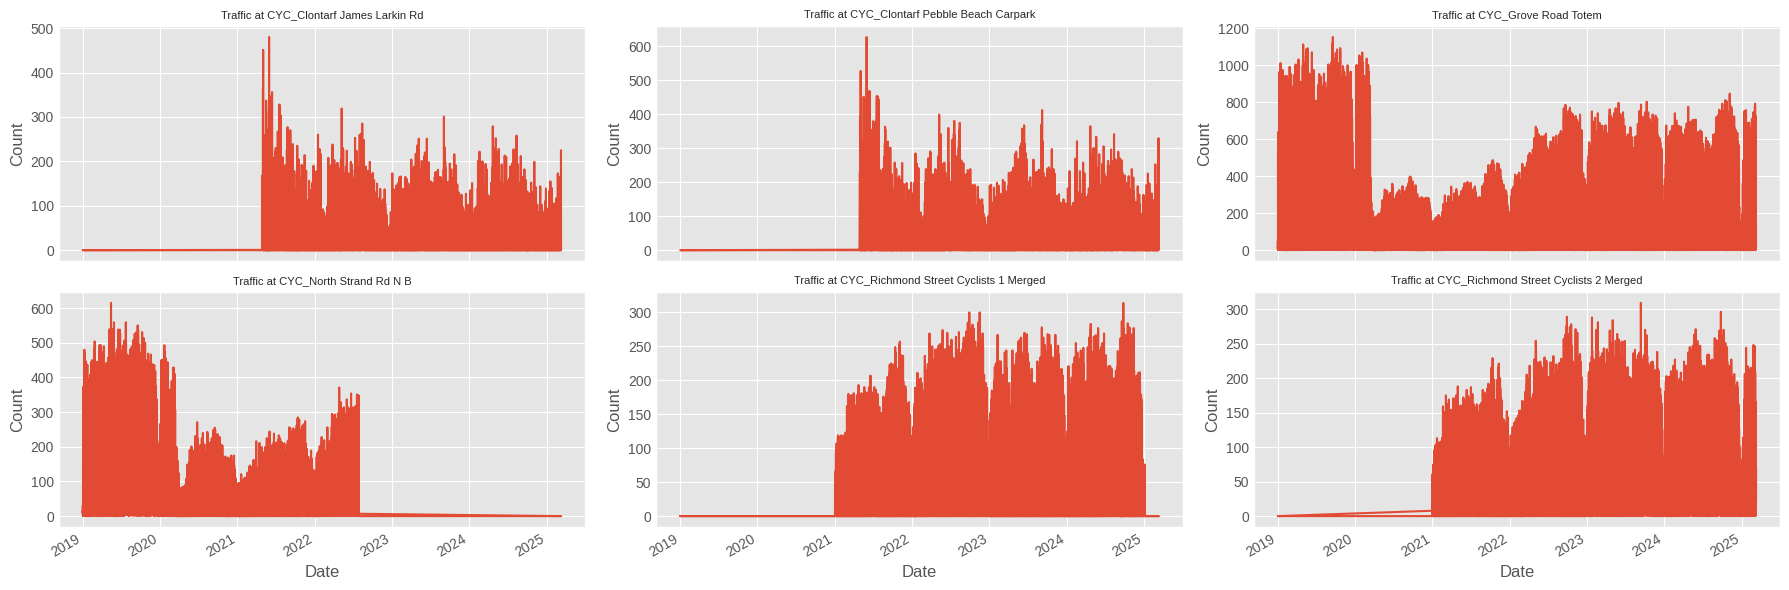

In [ ]:
plot_time_series_grid(cycle)